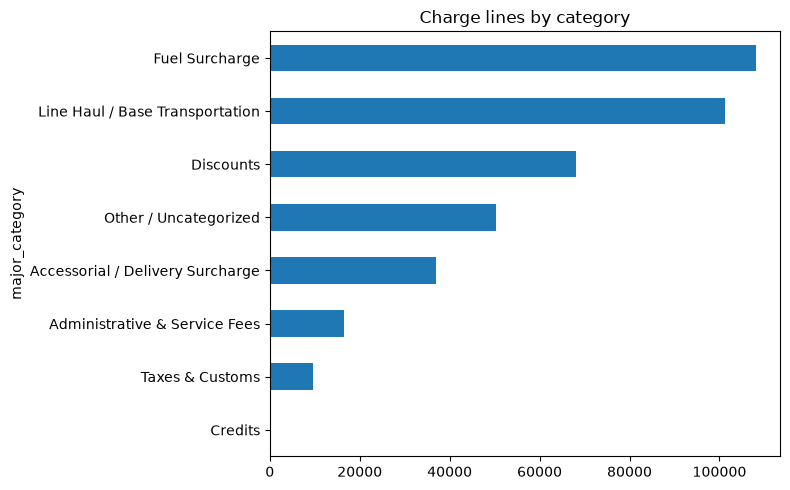

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
url = os.environ["SUPABASE_DB_URL"].replace("postgresql://", "postgresql+psycopg2://", 1)
engine = create_engine(url)

df = pd.read_sql("""
    SELECT major_category, sum(row_count) AS rows, sum(total_value) AS dollars
    FROM analytics.charge_mapping
    GROUP BY major_category
    ORDER BY rows DESC
""", engine)

df.plot.barh(x="major_category", y="rows", legend=False, figsize=(8, 5))
plt.title("Charge lines by category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()